In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

1. Відкрити та зчитати наданий файл з даними.

In [3]:
df = pd.read_csv("ПР4-пгр1.csv")
df

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,Class
0,0.266074,-0.165620,0.320980,0.483299,0.172340,0.273364,0.371178,0.929823,0.251173,0.159345,A
1,0.130292,0.870736,-3.210528,0.062493,0.261718,1.436060,1.465940,0.636203,0.282354,0.515587,A
2,-0.116585,0.069915,0.068476,-0.783147,0.261718,0.439463,-0.081827,-0.888236,-0.123005,0.582939,A
3,0.031541,0.297600,-3.210528,-0.583590,-0.721442,-0.307984,0.710932,1.051693,0.594169,-0.533994,A
4,0.229043,0.807926,-0.052442,0.082634,0.261718,0.148790,0.635431,0.051062,0.032902,-0.086652,F
...,...,...,...,...,...,...,...,...,...,...,...
8245,-0.338774,-0.094960,0.527252,1.857252,-1.257711,1.768258,-1.289840,0.919882,-0.247731,2.817610,X
8246,1.216550,0.156278,-0.013322,0.353593,0.172340,0.730137,0.484429,-0.418713,-0.777816,0.510500,A
8247,0.056229,0.054213,0.392108,-0.028960,0.261718,-1.346105,0.069175,0.788653,0.500624,-1.142223,H
8248,0.019197,-0.040001,0.288973,-0.042597,0.261718,0.148790,0.333428,-0.303949,-0.808997,0.057600,F


2. Визначити та вивести кількість записів.

In [4]:
print(f"Кількість записів: {df.shape[0]}")

Кількість записів: 8250


3. Вивести атрибути набору даних.

In [5]:
X = df.drop("Class", axis=1)
Y = df["Class"]

X.columns.tolist()

['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10']

4. З’ясувати збалансованість набору даних.

In [6]:
Y.value_counts()

Class
A    3422
F    1547
E     874
I     661
H     410
X     405
G     357
D     279
Y     208
C      87
Name: count, dtype: int64

5. Отримати двадцять варіантів перемішування набору даних та
розділення його на навчальну (тренувальну) та тестову вибірки,
використовуючи функцію ShuffleSplit. Сформувати начальну та тестові
вибірки на основі обраного користувачем варіанту .

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ShuffleSplit
from sklearn import set_config

set_config(transform_output="pandas")

scaler = StandardScaler()

ss = ShuffleSplit(n_splits=20, test_size=0.2, random_state=129)

all_splits = list(ss.split(X, Y))
train_index, test_index = all_splits[0]

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Y_train = Y.iloc[train_index]
Y_test = Y.iloc[test_index]


6. Використовуючи функцію KNeighborsClassifier бібліотеки scikit-learn,
збудувати класифікаційну модель на основі методу k найближчих
сусідів (кількість сусідів обрати самостійно, вибір аргументувати) та
навчити її на тренувальній вибірці, вважаючи, що цільова
характеристика визначається стовпчиком Class, а всі інші виступають в
ролі вихідних аргументів.

<function matplotlib.pyplot.show(close=None, block=None)>

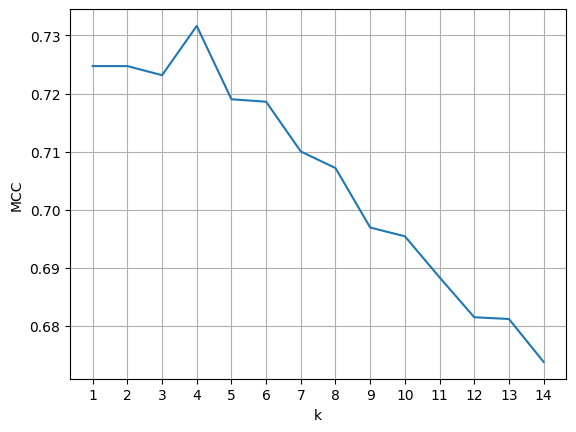

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import matthews_corrcoef, make_scorer
from sklearn.model_selection import cross_val_score

best_score = -1
best_k = 0

for k in range(1, 15):
	knn = KNeighborsClassifier(n_neighbors=k, weights='distance', p=1)
	knn.fit(X_train, Y_train)

	Y_test_pred = knn.predict(X_test)
	matthewscoef_train = matthews_corrcoef(Y_test, Y_test_pred)
	if matthewscoef_train > best_score:
		best_score = matthewscoef_train
		best_k = k

mean_scores = []

for k in range(1, 15):
	knn = KNeighborsClassifier(n_neighbors=k, weights='distance', p=1)
	
 
	mcc_scorer = make_scorer(matthews_corrcoef)
	scores = cross_val_score(knn, X_train, Y_train, cv=5, scoring=mcc_scorer)
	
	mean_score = scores.mean() 
	
	mean_scores.append(mean_score)
	if mean_score > best_score:
		best_score = mean_score
		best_k = k

knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', p=1)
knn.fit(X_train, Y_train)

plt.plot(range(1, 15), mean_scores)
plt.xticks(range(1,15))
plt.xlabel('k')
plt.ylabel('MCC')
plt.grid(True)
plt.show


7. Обчислити класифікаційні метрики збудованої моделі для тренувальної
та тестової вибірки. Представити результати роботи моделі на тестовій
вибірці графічно.

Коефіцієнт кореляції Мет'ю для тренувальної вибірки: 1.0
Коефіцієнт кореляції Мет'ю для тестової вибірки: 0.779922347477191

Звіт класифікації:
              precision    recall  f1-score   support

           A       0.83      0.90      0.86       669
           C       0.89      0.47      0.62        17
           D       0.86      0.75      0.80        51
           E       0.84      0.73      0.78       185
           F       0.78      0.79      0.78       329
           G       0.71      0.73      0.72        71
           H       0.73      0.63      0.68        76
           I       0.97      0.97      0.97       144
           X       0.94      0.91      0.93        69
           Y       0.94      0.82      0.88        39

    accuracy                           0.83      1650
   macro avg       0.85      0.77      0.80      1650
weighted avg       0.83      0.83      0.83      1650



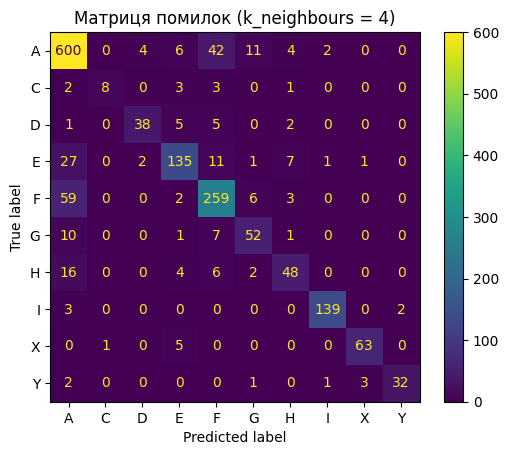

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

def evaluate_model(model, x_train, x_test, y_train, y_test):
  y_train_pred= model.predict(x_train)
  matthewscoef_train = matthews_corrcoef(y_train, y_train_pred)
  print(f"Коефіцієнт кореляції Мет'ю для тренувальної вибірки: {matthewscoef_train}")
  
  y_test_pred = model.predict(x_test)
  matthewscoef_test = matthews_corrcoef(y_test, y_test_pred)
  print(f"Коефіцієнт кореляції Мет'ю для тестової вибірки: {matthewscoef_test}")
  
  print("\nЗвіт класифікації:")
  print(classification_report(y_test, y_test_pred, zero_division=0))
  
  ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
  plt.title(f"Матриця помилок (k_neighbours = {model.n_neighbors})")
  plt.show

evaluate_model(knn, X_train, X_test, Y_train, Y_test)

8. Обрати алгоритм KDTree та з’ясувати вплив розміру листа (від 20 до
200 з кроком 5) на результати класифікації. Результати представити
графічно.

<function matplotlib.pyplot.show(close=None, block=None)>

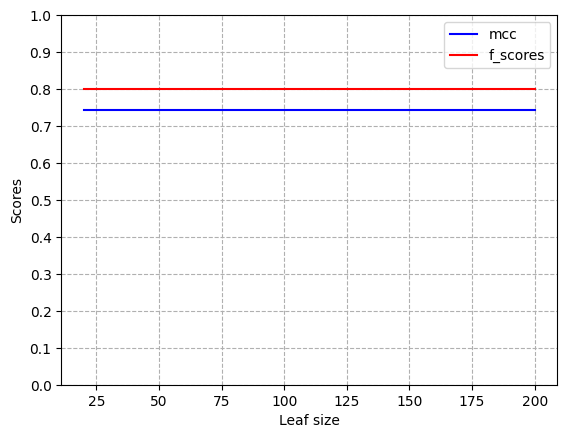

In [ ]:
from sklearn.metrics import f1_score 
import numpy as np 

leaf_sizes = range(20, 201, 5)

mcc_scores = []
f_scores = []

for leaf in leaf_sizes:
  knn = KNeighborsClassifier(n_neighbors=best_k, p=1, algorithm='kd_tree', leaf_size=leaf)
  
  knn.fit(X_train, Y_train)
  Y_pred = knn.predict(X_test)
  
  mcc_scores.append(matthews_corrcoef(Y_test, Y_pred))
  f_scores.append(f1_score(Y_test, Y_pred, average='weighted'))
  

plt.plot(leaf_sizes, mcc_scores, color='blue', label='mcc')
plt.plot(leaf_sizes, f_scores, color='red', label='f_scores')
plt.yticks(np.linspace(0, 1, 11))
plt.xlabel('Leaf size')
plt.ylabel('Scores')
plt.legend()

plt.grid(True, linestyle='--')
plt.show